In [1]:
import pickle
import shapely.geometry
import sklearn.ensemble
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import geopandas as gpd
import pyodbc
from pyproj import Proj
from mpl_toolkits.basemap import Basemap
os.chdir('C:/PhD/thesis/chapter1/channel')

### functions

In [2]:
#coordinates conversion
def convert_easting_northing_to_lat_lon(easting, northing,):
    proj = Proj('+proj=utm +zone=55 +south +ellps=GRS80 +units=m +no_defs')
    lon, lat = proj(easting, northing, inverse=True)
    return lat, lon

In [3]:
#convert asc file to geopandas
def asc2gpd(info,grid):

    #seperate text and int
    info['name']=[i.split(' ')[0] for i in info[0]]
    info['val']=[float(i.split(' ')[-1] )for i in info[0]]

    #convert to int for lower left x,y, nodatavalue and cell size
    xllcorner=info['val'][info['name']=='xllcorner'].item()
    xllcorner=int(xllcorner)
    yllcorner=info['val'][info['name']=='yllcorner'].item()
    yllcorner=int(round(yllcorner))
    cellsize=info['val'][info['name']=='cellsize'].item()
    cellsize=int(cellsize)
    nodataval=info['val'][info['name']=='NODATA_value'].item()
    nodataval=int(nodataval)

    #get coordinates in matrix form
    nrow=range(yllcorner,yllcorner+cellsize*grid.shape[0],cellsize)
    ncol=range(xllcorner,xllcorner+cellsize*grid.shape[1],cellsize)

    #flip y coordinates
    flatarr=[(i,j) for j in nrow for i in ncol]
    y=np.flip(np.array([i[1] for i in flatarr]).reshape(grid.shape),axis=0).flatten().tolist()

    #create geopandas
    export=pd.DataFrame()
    export['coords']=list(zip([i[0] for i in flatarr],y))
    export['altitude']=grid.flatten()
    export['coords'] = export['coords'].apply(shapely.geometry.Point)
    output=gpd.GeoDataFrame(export, geometry='coords')

    #remove nodata point
    output=output[output['altitude']!=nodataval]    
    
    return output

In [4]:
def asc2gpd(info, grid):
    # Parse info only once
    info_dict = {i.split(' ')[0]: float(i.split(' ')[-1]) for i in info[0]}
    
    # Extract necessary parameters
    xllcorner = int(info_dict['xllcorner'])
    yllcorner = int(round(info_dict['yllcorner']))
    cellsize = int(info_dict['cellsize'])
    nodataval = int(info_dict['NODATA_value'])
    
    # Generate row and column coordinates directly using numpy
    nrow = np.arange(yllcorner, yllcorner + cellsize * grid.shape[0], cellsize)
    ncol = np.arange(xllcorner, xllcorner + cellsize * grid.shape[1], cellsize)

    # Create a meshgrid for coordinates (avoiding loops)
    cols, rows = np.meshgrid(ncol, nrow)
    
    # Flatten the meshgrid to create coordinate pairs
    coordinates = np.vstack([cols.flatten(), rows.flatten()]).T
    
    # Flip y coordinates (reversing rows to match the expected orientation)
    coordinates[:, 1] = np.flip(coordinates[:, 1])
    
    # Create GeoDataFrame directly
    gdf = pd.DataFrame({
        'coords': [shapely.geometry.Point(x, y) for x, y in coordinates],
        'altitude': grid.flatten()
    })
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(gdf, geometry='coords')
    
    # Remove nodata points in a vectorized way
    gdf = gdf[gdf['altitude'] != nodataval]
    
    return gdf


### read data

In [5]:
df=pd.DataFrame(columns=['ID', 'SPECIES_CODE', 'SPECIES_NAME', 'CURRENT_SPECIES_NAME',
       'POPULATION', 'PREFERRED_COMMON_NAMES', 'PROJECT_CODE',
       'OBSERVATION_FOREIGN_ID', 'GDA94_ZONE_55_EASTINGNORTHING', 'LONGITUDE',
       'LATITUDE', 'EASTING', 'NORTHING', 'POSITION_ACCURACY', 'LOCATION_DESC',
       'OBSERVER_NAMES', 'OBSERVATION_DATE', 'DATE_ACCURACY',
       'OBSERVATION_TYPE', 'OBSERVATION_TYPE_QUALIFIER', 'OBSERVATION_STATE',
       'OBSERVATION_STATE_QUALIFIER', 'RECORD_STATUS', 'NOTES',
       'PRIMARY_IDENTIFIER',])

#species data come from https://www.naturalvaluesatlas.tas.gov.au/#NaturalValuesReportPage
for i in os.listdir():
    if '.csv' in i:
        data=pd.read_csv(i)
        df=pd.concat([df,data],axis=0)

### global variables

In [6]:
lonmin=146.874820
latmin=-43.307913
lonmax=147.387057
latmax=-42.95820098835541
lat_centre =-43.121608273454754; lon_centre = 147.15917683790045;
gridlen=40

In [7]:
locs={
'Woodbridge':(-43.16231201181594, 147.24096783495915),
'Sandfly':(-42.98109875801662, 147.18884370980504),
'Kettering':(-43.12824457628333, 147.25985058705248),
'Snug':(-43.066699777785686, 147.2617388626389),
'Kingston':(-42.989750064055585, 147.3042235683546),
"Blackman's Bay":(-43.00961221439889, 147.3309183996821),
'Cygnet':(-43.17071078470127, 147.08044408531794),
'Longley':(-42.96368, 147.18667),
'Margate':(-43.030571400998504, 147.27718838707887),
'Huonville':(-43.03350547850493, 147.04924331744954),
'Middleton':(-43.23661910302439, 147.2524184478446),
'Grove':(-42.989949618733235, 147.0952485673071)
}

In [8]:
#assign each coordinate to the grid cell id
lonunit=(lonmax-lonmin)/gridlen
latunit=(latmax-latmin)/gridlen
gridloc={}
for i in locs:
    latnum=(locs[i][0]-latmin)//latunit
    lonnum=(locs[i][1]-lonmin)//lonunit
    gridloc[i]=(int(latnum),int(lonnum))

#remove areas outside of grid cell range
for i in [j for j in gridloc]:
    if int(gridloc[i][0])>=gridlen or \
    int(gridloc[i][1])>=gridlen or \
    int(gridloc[i][0])<0 or int(gridloc[i][1])<0:
        print(i)
        del gridloc[i]

### island map

In [9]:
#create map
#alternative projection could be crs4236 wgs84
carte=Basemap(llcrnrlon=lonmin,llcrnrlat=latmin,
              urcrnrlon=lonmax,urcrnrlat=latmax,
              resolution='f', projection='tmerc', 
             lat_0=lat_centre,lon_0=lon_centre,)

carte.drawmapboundary(fill_color='w')
carte.fillcontinents(color='k',lake_color='w')
carte.drawcoastlines()
carte.drawrivers()
plt.savefig('./images/base.png',bbox_inches='tight',
                    pad_inches=-.05)
plt.clf()


#down scale image
baselayer=cv2.imread('./images/base.png',0)
baselayer=cv2.resize(baselayer,dsize=(gridlen,gridlen,),
                   interpolation=cv2.INTER_AREA)
        

<Figure size 640x480 with 0 Axes>

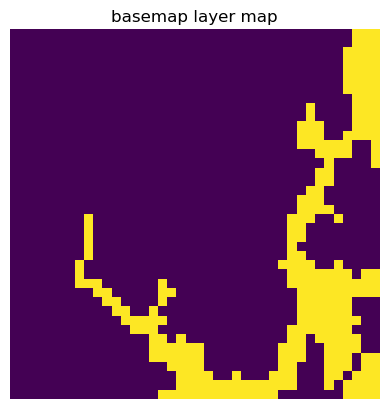

In [10]:
#manual dilution
baselayer[baselayer>=180]=255
baselayer[baselayer<180]=0
plt.imshow(baselayer)
plt.title('basemap layer map')
plt.axis('off')
plt.show()

In [11]:
df_baselayer=pd.DataFrame()
df_baselayer['grid']=baselayer.flatten()
df_baselayer.to_csv('./poems/baselayer.csv',index=False)

### NVA devil

In [12]:
os.chdir('C:/PhD/WildlifeDatabases')

In [17]:
traphist=pd.DataFrame(columns=['ID', 'TrapID', 'DateOfUse', 'Event', 'CaptureType', 'Microchip',
       'Comment'])

traps=pd.DataFrame(columns=['TrapID', 'Northing', 'Easting', 'Comments', 'TrapLine', 'Researcher'])

for i in [
 './Crabtree/CBT_database_2025_03_CRS.accdb',
 './Woodbridge+Sandfly/Channel_database_devil_2024_11_MH.accdb',
 './Franklin/FRA_database_devil_2023_09_CRS.accdb',
#     './Arthur River/ARV_database_2024_11_CRES.accdb',
#  './Black River/BRI_database_2022_11_KJS.accdb',
#  './Freycinet/FNP_database_2024_11_CRES.accdb',
#  './Takone/TKN_database_2022_12_ACW.accdb',
#  './West Pencil Pine/WPP_AUG_2024_MH.accdb',
#  './wukalina/Wukalina_NOV2020_SN.accdb'
]:

    conn = pyodbc.connect(r'Driver={Microsoft Access Driver (*.mdb, *.accdb)};DBQ='+f'{i};')
    traps=pd.concat([traps,pd.read_sql('select * from traps',conn)])
    traphist=pd.concat([traphist,pd.read_sql('select * from traphistory',conn)])
    traps.reset_index(inplace=True,drop=True)
    traphist.reset_index(inplace=True,drop=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\2291305380.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  traps=pd.concat([traps,pd.read_sql('select * from traps',conn)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\2291305380.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  traphist=pd.concat([traphist,pd.read_sql('select * from traphistory',conn)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\2291305380.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old b

In [18]:
#keep useful traps
traps=traps[['TrapID', 'Northing', 'Easting']].drop_duplicates().dropna()

#focus on recapture
traphist=traphist[traphist['Event'].isin(['Tasmanian devil','Tasmanian Devil',])].copy()

#remove null microchip
traphist=traphist.loc[traphist['Microchip'].dropna().index]

#remove duplicates
traphist=traphist.loc[traphist[['Microchip','DateOfUse']].drop_duplicates().index]

In [20]:
#merge
subset=traphist.merge(traps[['TrapID', 'Northing', 'Easting']],on='TrapID',how='left')

#remove empty coordinates
subset=subset.loc[subset[['Northing','Easting']].dropna().index]

In [21]:
subset['Northing']=subset['Northing'].str.replace('5224370.09\r\n5224370.09','5224370.09')
subset['Northing']=subset['Northing'].astype(float)

In [22]:
subset['lat'],subset['lon']=convert_easting_northing_to_lat_lon(subset['Easting'], subset['Northing'])

#locate where the devils are on a 20 by 20 raster
lonunit=(lonmax-lonmin)/gridlen
latunit=(latmax-latmin)/gridlen
subset['lat num']=(subset['lat']-latmin)//latunit
subset['lon num']=(subset['lon']-lonmin)//lonunit
subset['coordinates']=list(zip(subset['lat num'].astype(int),subset['lon num'].astype(int)))

#each individual in a given grid cell counts as one
subset=subset.loc[subset[['Microchip','coordinates']].drop_duplicates().index]

In [23]:
#create matrix
devilcount=subset.groupby(['coordinates']).count()
devil=np.zeros((gridlen,gridlen))
for i in range(len(devilcount)):
    loc=devilcount.index[i]
    if loc[0]>=gridlen or loc[0]<0 or loc[1]>=gridlen or loc[1]<0:
        continue
    devil[loc]=devilcount['Microchip'].iloc[i]

#flip matrix vertically
devil=np.flip(devil,0)

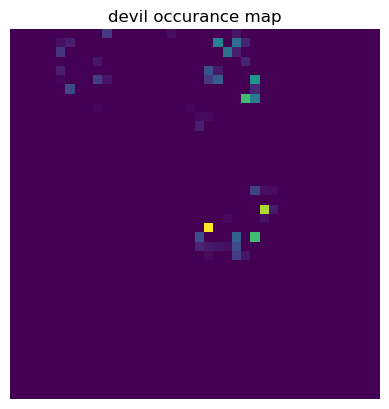

In [24]:
plt.imshow(devil)
plt.title('devil occurance map')
plt.axis('off')
plt.show()

### vegetation

In [25]:
os.chdir('C:/PhD/thesis/chapter1/channel')

In [26]:
# #convert stupid utm to lat lon
# zip1=gpd.read_file('./LIST_TASVEG_40_HUON_VALLEY/list_tasveg_40_huon_valley.shp')
# zip2=gpd.read_file('./LIST_TASVEG_40_KINGBOROUGH/list_tasveg_40_kingborough.shp')
# zips=pd.concat([zip1,zip2])
# zips = zips.to_crs('epsg:4326')
# #+proj=utm +zone=55 +south +ellps=GRS80 +units=m +no_defs
# zips.plot()
# plt.title('tasveg')
# plt.xlabel('lon')
# plt.ylabel('lat')
# plt.show()
# zips.to_file('./LIST_TASVEG_40_HUON_VALLEY/channel.shp', driver='ESRI Shapefile')

In [27]:
zips=gpd.read_file('./LIST_TASVEG_40_HUON_VALLEY/channel.shp')

C:\ProgramData\anaconda3\envs\geo\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [28]:
#crop to maria island
subset=zips.cx[lonmin:lonmax,
              latmin:latmax]

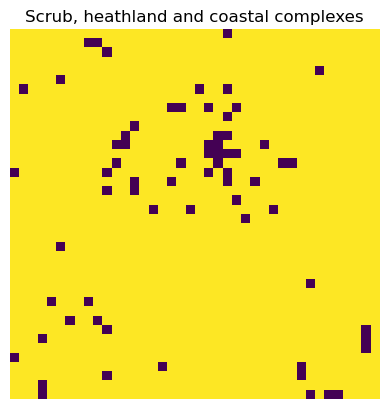

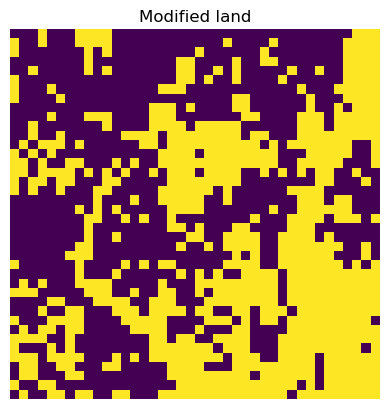

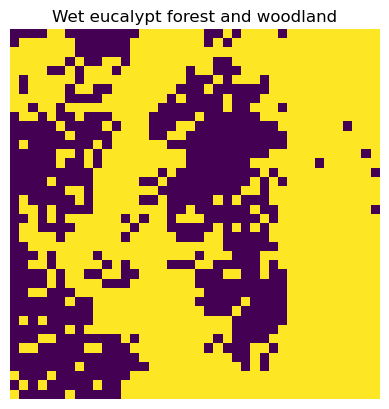

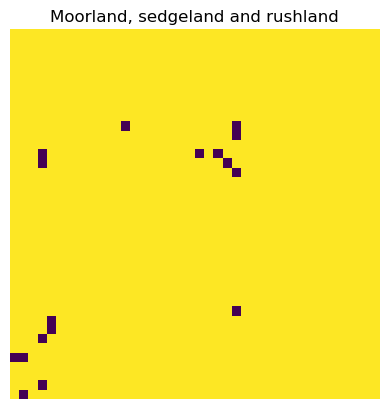

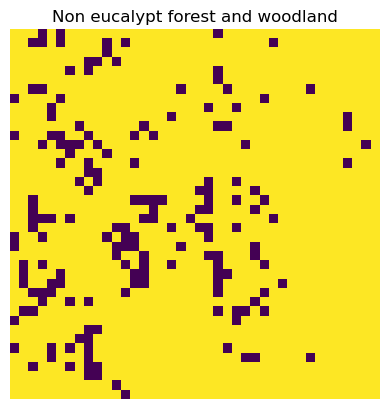

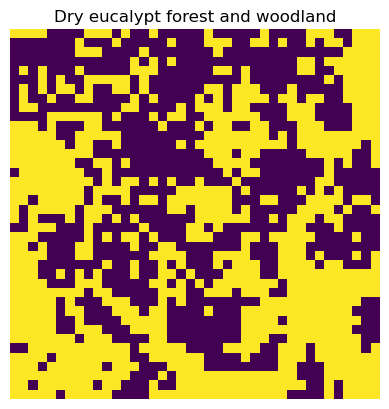

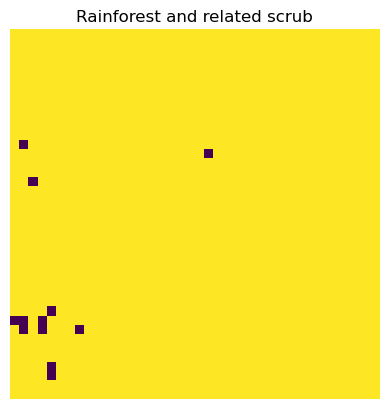

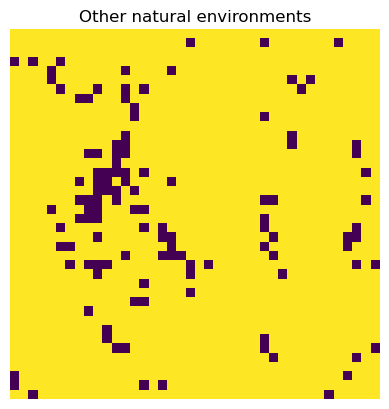

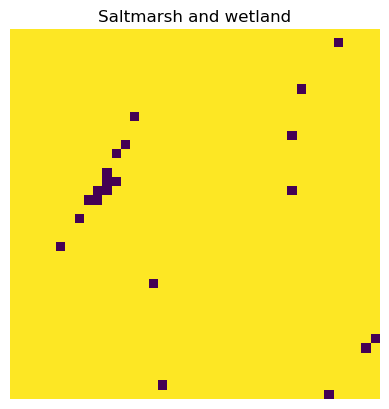

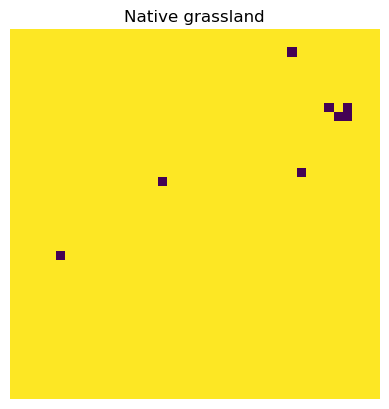

In [29]:
#plot each vegetation type
veg_group={}
for i in subset["VEG_GROUP"].unique():
    subsub=subset[subset["VEG_GROUP"]==i]
    ax=subsub.plot(column="VEG_GROUP")
    ax.set_xlim((lonmin,lonmax))
    ax.set_ylim((latmin,latmax))
    ax.axis('off')    
    plt.savefig(f'./images/{i}.png',bbox_inches='tight',
                    pad_inches=-.05)
    plt.clf()    
    plt.clf()

    #down scale image
    vegtype=cv2.imread(f'./images/{i}.png',0)
    vegtype=cv2.resize(vegtype,dsize=(gridlen,gridlen),
                       interpolation=cv2.INTER_LANCZOS4)
    vegtype[vegtype<255]=0
    veg_group[i]=vegtype
    plt.imshow(veg_group[i])
    plt.title(i)
    plt.axis('off')
    plt.show()

### elevation

In [30]:
# #read asc file into matrix
# grid=np.loadtxt("./LIST_DEM_25M_HUON_VALLEY/list_dem_25m_huon_valley.asc", skiprows=6)

# #read the header of asc file to map the coordinates
# info=pd.read_csv("./LIST_DEM_25M_HUON_VALLEY/list_dem_25m_huon_valley.asc",header=None, nrows=6)

# output1=asc2gpd(info,grid)

# #read asc file into matrix
# grid=np.loadtxt("./LIST_DEM_25M_KINGBOROUGH/list_dem_25m_kingborough.asc", skiprows=6)

# #read the header of asc file to map the coordinates
# info=pd.read_csv("./LIST_DEM_25M_KINGBOROUGH/list_dem_25m_kingborough.asc",header=None, nrows=6)

# output2=asc2gpd(info,grid)

# #merge
# output=pd.concat([output1,output2])

# output.reset_index(inplace=True,drop=True)

# #convert coordinates
# output=gpd.read_file('./LIST_TASVEG_40_HUON_VALLEY/height.shp')
# output=output.set_crs(zips.crs)
# output=output.to_crs('epsg:4326')

# subset=output.cx[lonmin:lonmax,
#               latmin:latmax]

# #convert matrix to raster
# subset['lon']=subset['geometry'].apply(lambda x:x.xy[0][0])
# subset['lat']=subset['geometry'].apply(lambda x:x.xy[1][0])
# lonunit=(lonmax-lonmin)/gridlen
# latunit=(latmax-latmin)/gridlen
# subset['lat num']=(subset['lat']-latmin)//latunit
# subset['lon num']=(subset['lon']-lonmin)//lonunit
# subset['id']=list(zip(subset['lat num'].astype(int),subset['lon num'].astype(int)))

# #compute mean altitude by each cell
# height=subset[['id','altitude']].groupby('id').mean()['altitude']

# #export
# pd.DataFrame(height).to_csv('height.csv')

In [31]:
height=pd.read_csv('height.csv')

In [32]:
#generate raster
altitude=np.zeros(devil.shape)
for i in range(len(height)):
    altitude[eval(height.at[i,'id'])]=height.at[i,'altitude']
altitude=np.flip(altitude,axis=0)

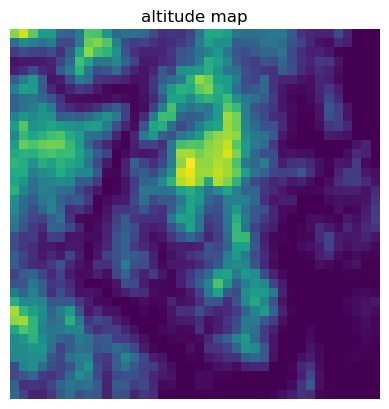

In [33]:
#viz
plt.imshow(altitude)
plt.title('altitude map')
plt.axis('off')
plt.show()

### matrix form

In [34]:
#generate data
data=pd.DataFrame()
data['devil']=devil.flatten()

#create habitat suitability index
#use log to reduce the scale\
data['devil'][data['devil']==0]=np.nan
data['index']=np.log(data['devil']+1)/np.log(data['devil']).max()
arr=altitude.flatten()
data['altitude']=arr

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\4181235077.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['devil'][data['devil']==0]=np.nan


In [35]:
#convert array to binary
arr=baselayer.flatten()
arr[arr==0]=1
arr[arr==255]=0
data['base']=arr

for i in veg_group:
    arr=veg_group[i].flatten()
    arr[arr==0]=1
    arr[arr==255]=0
    data[i]=arr

In [36]:
#keep channel area and remove the rest
mask=pd.read_csv('mask.csv',header=None)
flatmask=np.array(mask).flatten()
actual_channel_ind=np.where(flatmask==0)[0]


data['base'].loc[list(set(data[data['base']==1].index).difference(set(actual_channel_ind)))]=0
data['index'][data['base']==0]=0

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\3611752926.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['base'].loc[list(set(data[data['base']==1].index).difference(set(actual_channel_ind)))]=0
C:\Users\Administrator\App

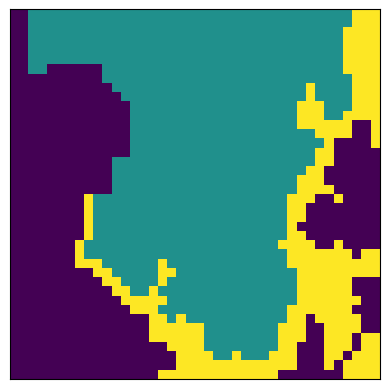

In [37]:
area=baselayer.copy()

area[np.array(mask)==0]=128

plt.xticks([])
plt.yticks([])
plt.imshow(area)

### random forest

In [38]:
#remove sea area
land=data[data['base']==1]

#only work on the cells with recorded devil capture
training=land.loc[land['index'].dropna().index]

In [39]:
#train and predict

targets=[i for i in training.columns if i not in ['devil','base','index']]
clf=sklearn.ensemble.RandomForestRegressor()

clf.fit(training[targets],training['index'])

land['pred']=clf.predict(land[targets])

data['pred']=land['pred']

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\3513440024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land['pred']=clf.predict(land[targets])


In [40]:
#not bad for scarce data points
clf.score(training[targets],training['index'])

0.8271187605577022

In [41]:
data['pred'].min(),data['pred'].max()

(0.2421284456679529, 0.8462646986914945)

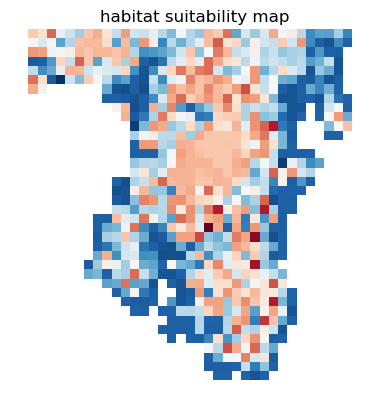

In [42]:
#viz habitat suitability map
plt.imshow(np.array(data['pred']).reshape(gridlen,gridlen),cmap='RdBu_r')#, vmin=0.1, vmax=0.9
plt.title('habitat suitability map')
plt.axis('off')
plt.show()

### chapter 1 model

In [43]:
col_order=['altitude', 'disease', 'Dry eucalypt forest and woodland',
       'Highland and treeless vegetation', 'Modified Land', 'Modified land',
       'Moorland, sedgeland and rushland', 'Native grassland',
       'Non eucalypt forest and woodland', 'Other natural environments',
       'Rainforest and related scrub', 'Saltmarsh and wetland',
       'Scrub, heathland and coastal complexes',
       'Wet eucalypt forest and woodland']

In [44]:
#load chapter 1 model
with open('C:/PhD/thesis/chapter1/tasmania/poems/habitat_suitability.pkl', 'rb') as file:
    clf = pickle.load(file)

C:\ProgramData\anaconda3\envs\geo\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\ProgramData\anaconda3\envs\geo\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [45]:
#assign missing col
for i in col_order:
    if i not in land:
        land[i]=0

land['disease']=1

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\54384431.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land[i]=0
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\54384431.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land[i]=0
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\54384431.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [46]:
land['pred2']=clf.predict(land[col_order])

data['pred2']=land['pred2']

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3252\4213572073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land['pred2']=clf.predict(land[col_order])


In [47]:
data['pred2'].min(),data['pred2'].max()

(0.6948368134996312, 0.8599135359680822)

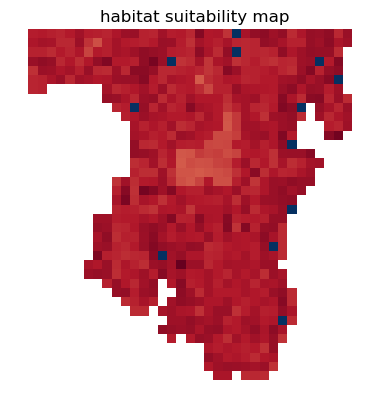

In [48]:
#viz habitat suitability map
matrix=np.array(data['pred2']).reshape(gridlen,gridlen)
matrix=np.flip(matrix,axis=0)
for i in gridloc:
    matrix[gridloc[i]]=0
matrix=np.flip(matrix,axis=0)
plt.imshow(matrix,cmap='RdBu_r')#, vmin=0.1, vmax=0.9
plt.title('habitat suitability map')
plt.axis('off')
plt.show()

### export

In [44]:
land['pred'].loc[land['index'].dropna().index]=land['index'][land['index'].dropna().index].tolist()

C:\Users\tm\AppData\Local\Temp\ipykernel_26524\1000287191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land['pred'].loc[land['index'].dropna().index]=land['index'][land['index'].dropna().index].tolist()


In [45]:
land[['pred']].dropna().to_csv('./poems/suitability.csv',index=False)

In [46]:
#create map data
arr=data['base'].to_numpy()
arr[arr==0]=255
arr[arr==1]=0
df_baselayer=pd.DataFrame()
df_baselayer['grid']=arr
df_baselayer.to_csv('./poems/baselayer.csv',index=False)

In [47]:
#convert lattice to adjacency list
check_matrix=arr.reshape(gridlen,gridlen)
adj_list={}

for i in range(gridlen**2):
    current_tile=[i//gridlen,i%gridlen]
    
    if check_matrix[current_tile[0],current_tile[1]]==0:
        adj_list[i]=[]
        
        up=[current_tile[0]-1,current_tile[1]]
        down=[current_tile[0]+1,current_tile[1]]
        left=[current_tile[0],current_tile[1]-1]
        right=[current_tile[0],current_tile[1]+1]

        
        if up[0]>=0 and check_matrix[current_tile[0]-1,current_tile[1]]==0:
            adj_list[i].append(i-gridlen)

        if down[0]<gridlen and check_matrix[current_tile[0]+1,current_tile[1]]==0:
            adj_list[i].append(i+gridlen)
        
        if left[1]>=0 and check_matrix[current_tile[0],current_tile[1]-1]==0:
            adj_list[i].append(i-1)

        if right[1]<gridlen and check_matrix[current_tile[0],current_tile[1]+1]==0:
            adj_list[i].append(i+1)
            

In [48]:
#use bfs to identify the grids required for validation within the radius
counter=0
stop=False
lvl={}
lvl[0]=training[training['index']!=0].index.tolist()
radius=12
while not stop:
    
    queue=[]
    counter+=1
    if counter==radius:
        stop=True
    for i in list(lvl.values())[-1]:
        queue+=adj_list[i]
    lvl[counter]=list(set(queue))

validation_target=sorted(list(set([j for i in lvl.values() for j in i])))

In [49]:
#create validation area file
valid=pd.DataFrame(index=df_baselayer.index)
valid['target']=0
valid['target'].loc[validation_target]=1
valid.to_csv('./poems/validation.csv',index=False)

In [50]:
#reindex validation area against land area
land['ID']=range(len(land))
identity=pd.DataFrame()
identity['ID']=land['ID'].loc[validation_target].tolist()
identity.to_csv('./poems/identity.csv',index=False)

C:\Users\tm\AppData\Local\Temp\ipykernel_26524\617944699.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land['ID']=range(len(land))
